In the lab, a classification tree was applied to the Carseats data set af- ter converting Sales into a qualitative response variable. Now we will seek to predict Sales using regression trees and related approaches, treating the response as a quantitative variable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ISLP import load_data
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [2]:
#1. 載入數據
Carseats = load_data('Carseats')

# 2. 數據預處理
# 決策樹在 sklearn 中無法直接處理字串類別變數 (ShelveLoc, Urban, US)
# 我們需要使用 get_dummies 將其轉換為數值 (One-Hot Encoding)
# drop_first=True 是統計學上的標準做法 (避免共線性)，但對樹模型來說 drop_first=False 也可以
df = pd.get_dummies(Carseats, columns=['ShelveLoc', 'Urban', 'US'], drop_first=True)

# 定義 X (特徵) 和 y (目標: Sales)
X = df.drop('Sales', axis=1)
y = df['Sales']

print("Data Shape:", X.shape)
X.head()

Data Shape: (400, 11)


,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
0,138,73,11,276,120,42,17,False,False,True,True
1,111,48,16,260,83,65,10,True,False,True,True
2,113,35,10,269,80,59,12,False,True,True,True
3,117,100,4,466,97,55,14,False,True,True,True
4,141,64,3,340,128,38,13,False,False,True,False


**(a)** Split the data set into a training set and a test set.

In [3]:
# 定義 X (特徵) 和 y (目標)
X = df.drop(columns=['Sales'])
y = df['Sales']

# 分割資料集 (50% train, 50% test，這是 ISLP 常用的比例)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (200, 11)
Test set shape: (200, 11)


**(b)** Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

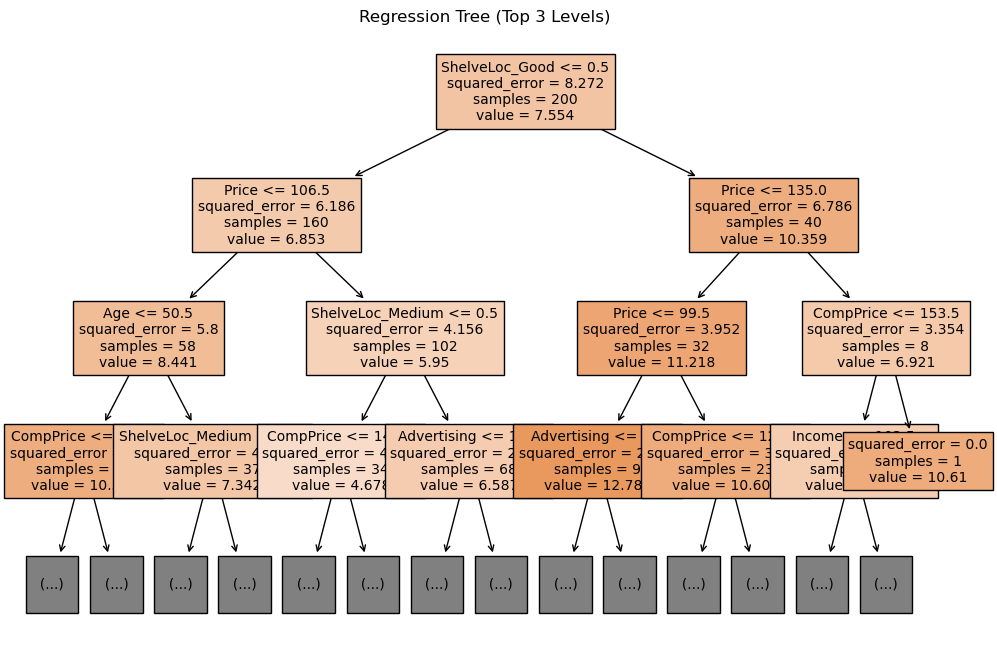

Full Tree Test MSE: 6.4678


In [6]:
# 1. 擬合回歸樹
tree_reg = DecisionTreeRegressor(random_state=1)
tree_reg.fit(X_train, y_train)

# 2. 繪製樹狀圖 (修正部分：加上 .tolist())
plt.figure(figsize=(12, 8))
plot_tree(tree_reg, 
          feature_names=X.columns.tolist(),  # <--- 這裡加上 .tolist() 解決報錯
          filled=True, 
          max_depth=3, 
          fontsize=10)
plt.title("Regression Tree (Top 3 Levels)")
plt.show()

# 3. 計算 Test MSE
y_pred_tree = tree_reg.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)

print(f"Full Tree Test MSE: {mse_tree:.4f}")

# 解釋 (Interpretation):
# 根節點通常是 'ShelveLoc_Good' 或 'Price'，表示這兩個變數對銷量影響最大。
# 若 ShelveLoc 不是 Good 且 Price 較高，銷量通常較低。

**(c)** Use cross-validation in order to determine the optimal level of tree complexity. Does pruning the tree improve the test MSE?

In [7]:
# 1. 取得 Cost Complexity Pruning 的路徑 (候選 alphas)
path = tree_reg.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[:-1] # 去除最後一個 alpha (會導致只剩根節點)

# 2. 使用 Grid Search CV 尋找最佳 alpha
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=1),
    param_grid={'ccp_alpha': ccp_alphas},
    cv=5,
    scoring='neg_mean_squared_error'
)
grid_search.fit(X_train, y_train)

# 3. 取得最佳模型並預測
best_pruned_tree = grid_search.best_estimator_
y_pred_pruned = best_pruned_tree.predict(X_test)
mse_pruned = mean_squared_error(y_test, y_pred_pruned)

print(f"Best alpha: {grid_search.best_params_['ccp_alpha']:.5f}")
print(f"Pruned Tree Test MSE: {mse_pruned:.4f}")
print(f"MSE Improvement: {mse_tree - mse_pruned:.4f}")

# 結論: 若 Pruned MSE < Full Tree MSE，則剪枝改進了模型。
# 通常剪枝能減少過度擬合 (Overfitting)。

Best alpha: 0.21045
Pruned Tree Test MSE: 5.3007
MSE Improvement: 1.1671


**(d)** Use the bagging approach in order to analyze this data. What test MSE do you obtain? Use the `feature_importance_` values to determine which variables are most important.

In [8]:
# Bagging 其實就是 Random Forest 的特例，其中 max_features = p (所有特徵)
p = X_train.shape[1]
bagging_reg = RandomForestRegressor(max_features=p, n_estimators=500, random_state=1)
bagging_reg.fit(X_train, y_train)

# 計算 MSE
y_pred_bag = bagging_reg.predict(X_test)
mse_bag = mean_squared_error(y_test, y_pred_bag)

print(f"Bagging Test MSE: {mse_bag:.4f}")

# Feature Importance
importances_bag = pd.Series(bagging_reg.feature_importances_, index=X.columns)
print("\nTop 5 Important Variables (Bagging):")
print(importances_bag.sort_values(ascending=False).head(5))

Bagging Test MSE: 2.8348

Top 5 Important Variables (Bagging):
Price               0.298016
ShelveLoc_Good      0.231293
Age                 0.106672
CompPrice           0.083806
ShelveLoc_Medium    0.083775
dtype: float64


**(e)** Use random forests to analyze this data. What test MSE do you obtain? Use the `feature_importance_` values to determine which variables are most important. Describe the effect of $m$, the number of variables considered at each split, on the error rate obtained.

In [9]:
# Random Forest: max_features 通常設為 sqrt(p) 或 p/3
# 這裡我們使用 sqrt (sklearn 預設值之一) 或手動指定整數
rf_reg = RandomForestRegressor(max_features='sqrt', n_estimators=500, random_state=1)
rf_reg.fit(X_train, y_train)

# 計算 MSE
y_pred_rf = rf_reg.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print(f"Random Forest Test MSE: {mse_rf:.4f}")

# Feature Importance
importances_rf = pd.Series(rf_reg.feature_importances_, index=X.columns)
print("\nTop 5 Important Variables (Random Forest):")
print(importances_rf.sort_values(ascending=False).head(5))

# 關於 m 的影響:
# 減少 m (每個分裂點考慮的變數數量) 可以降低樹之間的相關性 (Decorrelate trees)。
# 當數據中有很強的預測變數 (如 Price) 時，Bagging 的每棵樹都會優先選它，導致樹長得很像。
# Random Forest 強制樹去考慮其他變數，從而降低整體的變異 (Variance)，通常能得到比 Bagging 更低的 MSE。

Random Forest Test MSE: 2.9505

Top 5 Important Variables (Random Forest):
Price             0.246488
ShelveLoc_Good    0.169870
Age               0.112096
CompPrice         0.095081
Advertising       0.089816
dtype: float64


**(f)** Now analyze the data using BART, and report your results.

In [11]:
# 處理 BART 的資料型態問題
# Pandas 新版 get_dummies 會產生 bool 型態，BART 處理時會報錯
# 解決方案：強制轉換為 float
X_train_bart = X_train.astype(float)
X_test_bart = X_test.astype(float)
y_train_bart = y_train.astype(float) # 確保目標變數也是數值 (通常已經是，但保險起見)

try:
    from ISLP.bart import BART
    
    # 設定 BART 參數 (ISLP 實作)
    bart_model = BART(random_state=1, burnin=500, ndraw=2000)
    
    # 擬合模型 (使用轉型後的資料)
    bart_model.fit(X_train_bart, y_train_bart)
    
    # 預測
    y_pred_bart = bart_model.predict(X_test_bart)
    
    # 計算 MSE
    mse_bart = mean_squared_error(y_test, y_pred_bart)
    
    print(f"BART Test MSE: {mse_bart:.4f}")
    
except ImportError:
    print("ISLP package not installed or BART module not found.")
    print("Please install via: pip install ISLP")
except Exception as e:
    print(f"An error occurred: {e}")

BART Test MSE: 1.4600
